# Reliable fine-tuning of MACE foundation models

This notebook was made by Eszter Varga-Umbrich and Tamás Lajos Tompa.

Fine-tuning works well when done correctly, but there are pitfalls: it can also improve a validation error while making the potential less physical and robust away from the training structures. This short tutorial uses the released data from [*Fine-tuning MLIP foundation models: strategies for accuracy and transferability*](https://arxiv.org/abs/2606.12704) to separate three questions:

1. Are the atomic reference energies (`E0s`) consistent with the foundation model?
2. Are the optimiser settings appropriate for the fine-tuning method?
3. Does the trained model preserve the physical behaviour needed by the application?

The plots run on CPU in a few minutes and download less than 10 MB. The training example is an opt-in because even this small S$_\mathrm{N}$2 example requires a GPU.

> This notebook needs `numpy` and `matplotlib` for the default path. To run the training cell, install `mace-torch>=0.3.15` (for example, `%pip install "mace-torch>=0.3.15"`).

## 1. Download only the files needed

The full supplementary repository is about 100 GB so cloning it is inconvenient. We fetch only the S$_\mathrm{N}$2 structures, replay structures, archived curves, and compact training logs used below.

In [1]:
from pathlib import Path
from importlib import metadata
from urllib.request import Request, urlopen
import os
import re
import shutil

WORK = Path(os.environ.get("MACE_TUTORIAL_WORKDIR", "finetuning_tutorial_work"))
DATA_DIR = WORK / "paper_data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str((WORK / "matplotlib-cache").resolve()))

import numpy as np
import matplotlib.pyplot as plt

REPO = "ev-tlt/MACE_finetuning_supplementary"
REVISION = "e132ea4317a4cd1426498af8cfca24ebe88fd498"
BASE_URL = f"https://huggingface.co/datasets/{REPO}/resolve/{REVISION}"

FILES = {
    # Controlled E0 study: 60 reaction structures and no isolated-atom rows.
    "train_estimated": "sn2/evals_additional/sn2-avg_vs_est_E0/data/train.xyz",
    # Main paper train set: the same 60 structures plus five isolated atoms.
    "train_explicit": "sn2/data/train.xyz",
    "valid": "sn2/data/valid.xyz",
    "test": "sn2/data/test.xyz",
    "replay": "foundation-utils/omat24_filtered_sn2.extxyz",
    "e0_curves": "sn2/evals_additional/sn2-avg_vs_est_E0/dimers/dimer_curves_e0_data.npz",
    # Multihead learning-rate sweep.
    "lr_1e-4": "sn2/training_runs_new/mh_ps/slurm-1614824_4294967294.out",
    "lr_1e-3": "ablations/multihead_lr/sn2/elem_matched_lr1e-3/logs/SN2_multihead_pseudolabel_run-1.log",
    "lr_1e-2": "ablations/multihead_lr/sn2/elem_matched_lr1e-2/logs/SN2_multihead_pseudolabel_run-1.log",
    # Constant loss weights and two Stage-Two (legacy `swa`) schedules.
    "stage_constant": "water/training_runs_medium/Ih/100/Naive/slurm-1579755_4294967294.out",
    "stage_same_lr": "ablations/twostage_training/loss_balance_tuned/water_Ih/logs/ice_MACE_model_lbt_run-1.log",
    "stage_lower_lr": "ablations/twostage_training/loss_balance_tuned/water_Ih_orig/logs/ice_MACE_model_lbt_run-1.log",
}

def download_hf_file(remote_path):
    target = DATA_DIR / remote_path
    if target.exists() and target.stat().st_size > 0:
        return target
    target.parent.mkdir(parents=True, exist_ok=True)
    partial = target.with_suffix(target.suffix + ".part")
    request = Request(f"{BASE_URL}/{remote_path}", headers={"User-Agent": "mace-finetuning-tutorial"})
    try:
        with urlopen(request) as response, partial.open("wb") as output:
            shutil.copyfileobj(response, output)
        partial.replace(target)
    finally:
        partial.unlink(missing_ok=True)
    return target

LOCAL = {name: download_hf_file(path) for name, path in FILES.items()}
print(f"Downloaded/verified {sum(p.stat().st_size for p in LOCAL.values()) / 1e6:.1f} MB in {DATA_DIR}")

def inspect_extxyz(path):
    frames = isolated_atoms = 0
    with path.open(errors="replace") as handle:
        while True:
            line = handle.readline()
            if not line:
                break
            if not line.strip():
                continue
            n_atoms = int(line)
            header = handle.readline()
            frames += 1
            isolated_atoms += "config_type=IsolatedAtom" in header
            for _ in range(n_atoms):
                handle.readline()
    return frames, isolated_atoms

for name in ("train_estimated", "train_explicit", "valid", "test", "replay"):
    frames, isolated = inspect_extxyz(LOCAL[name])
    print(f"{name:>16}: {frames:4d} configurations, {isolated} isolated-atom rows")

try:
    MACE_VERSION = metadata.version("mace-torch")
except metadata.PackageNotFoundError:
    MACE_VERSION = None
print("mace-torch:", MACE_VERSION or "not installed (plots still work)")

Matplotlib is building the font cache; this may take a moment.


Downloaded/verified 8.9 MB in finetuning_tutorial_work/paper_data
 train_estimated:   60 configurations, 0 isolated-atom rows
  train_explicit:   65 configurations, 5 isolated-atom rows
           valid:   60 configurations, 0 isolated-atom rows
            test:   60 configurations, 0 isolated-atom rows
          replay: 3706 configurations, 0 isolated-atom rows
mace-torch: 0.3.5


## 2. E0s are part of the physical model

MACE learns interaction energies relative to one isolated-atom reference energy $E_0^Z$ per element. When the target labels use a different electronic-structure setup from pretraining, the atomic baselines can shift. There are three options to handle this:

- **Explicit isolated-atom calculations** at the target level of theory are the gold standard.
- **`--E0s=estimated`** fits corrections to the *foundation model E0s* and is the recommended default when isolated-atom calculations are unavailable.
- **`--E0s=average`** fits total energies of interacting structures as elemental contributions. Those numbers are not isolated-atom energies and are a poor fine-tuning reference.

The next plot uses archived models trained on the controlled 60-structure file. Every curve is shifted to zero at its largest separation, so the comparison is about the learned interaction shape rather than the arbitrary absolute offset.

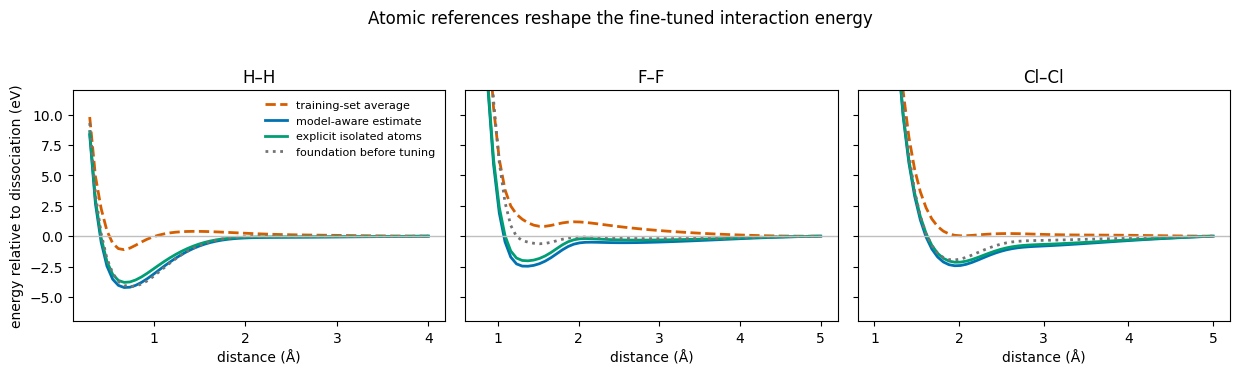

In [2]:
curves = np.load(LOCAL["e0_curves"])
pairs = [("H_H", "H–H"), ("F_F", "F–F"), ("Cl_Cl", "Cl–Cl")]
methods = {
    "Average_E0": ("training-set average", "#D55E00", "--"),
    "Estimated_E0": ("model-aware estimate", "#0072B2", "-"),
    "Isolated_E0": ("explicit isolated atoms", "#009E73", "-"),
    "MACE_OMat_0_medium": ("foundation before tuning", "0.45", ":"),
}

fig, axes = plt.subplots(1, len(pairs), figsize=(12.5, 3.6), sharey=True)
for ax, (pair_key, title) in zip(axes, pairs):
    for method, (label, color, linestyle) in methods.items():
        distance = curves[f"{method}_{pair_key}_distances"]
        energy = curves[f"{method}_{pair_key}_mean"]
        interaction_energy = energy - energy[-1]
        ax.plot(distance, interaction_energy, label=label, color=color, ls=linestyle, lw=2)
    ax.axhline(0.0, color="0.75", lw=1)
    ax.set(title=title, xlabel="distance (Å)", ylim=(-7, 12))
axes[0].set_ylabel("energy relative to dissociation (eV)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Atomic references reshape the fine-tuned interaction energy", y=1.03)
fig.tight_layout()
plt.show()

The averaged-E0 fits make the H–H well much too shallow and remove the bound F–F and Cl–Cl minima altogether. The estimated-E0 curves closely follow the explicit-isolated-atom curves in the chemically relevant region. This is why a bad E0 choice is not repaired by saying that it is "only a constant": during optimisation, the network is forced to absorb the inconsistent baseline and the learned potential-energy surface changes.

There is an even stronger downstream test for ice: averaged-E0 models looked converged on pointwise metrics yet produced unstable molecular dynamics, whereas the reestimated-E0 models remained stable.

## 3. Choose a fine-tuning strategy and its hyperparameters

Fine-tuning strategies differ in which parameters can change and whether replay data are used to preserve the pretrained domain. The schematic compares the four strategies used below, with from-scratch training and the untouched foundation model as references.

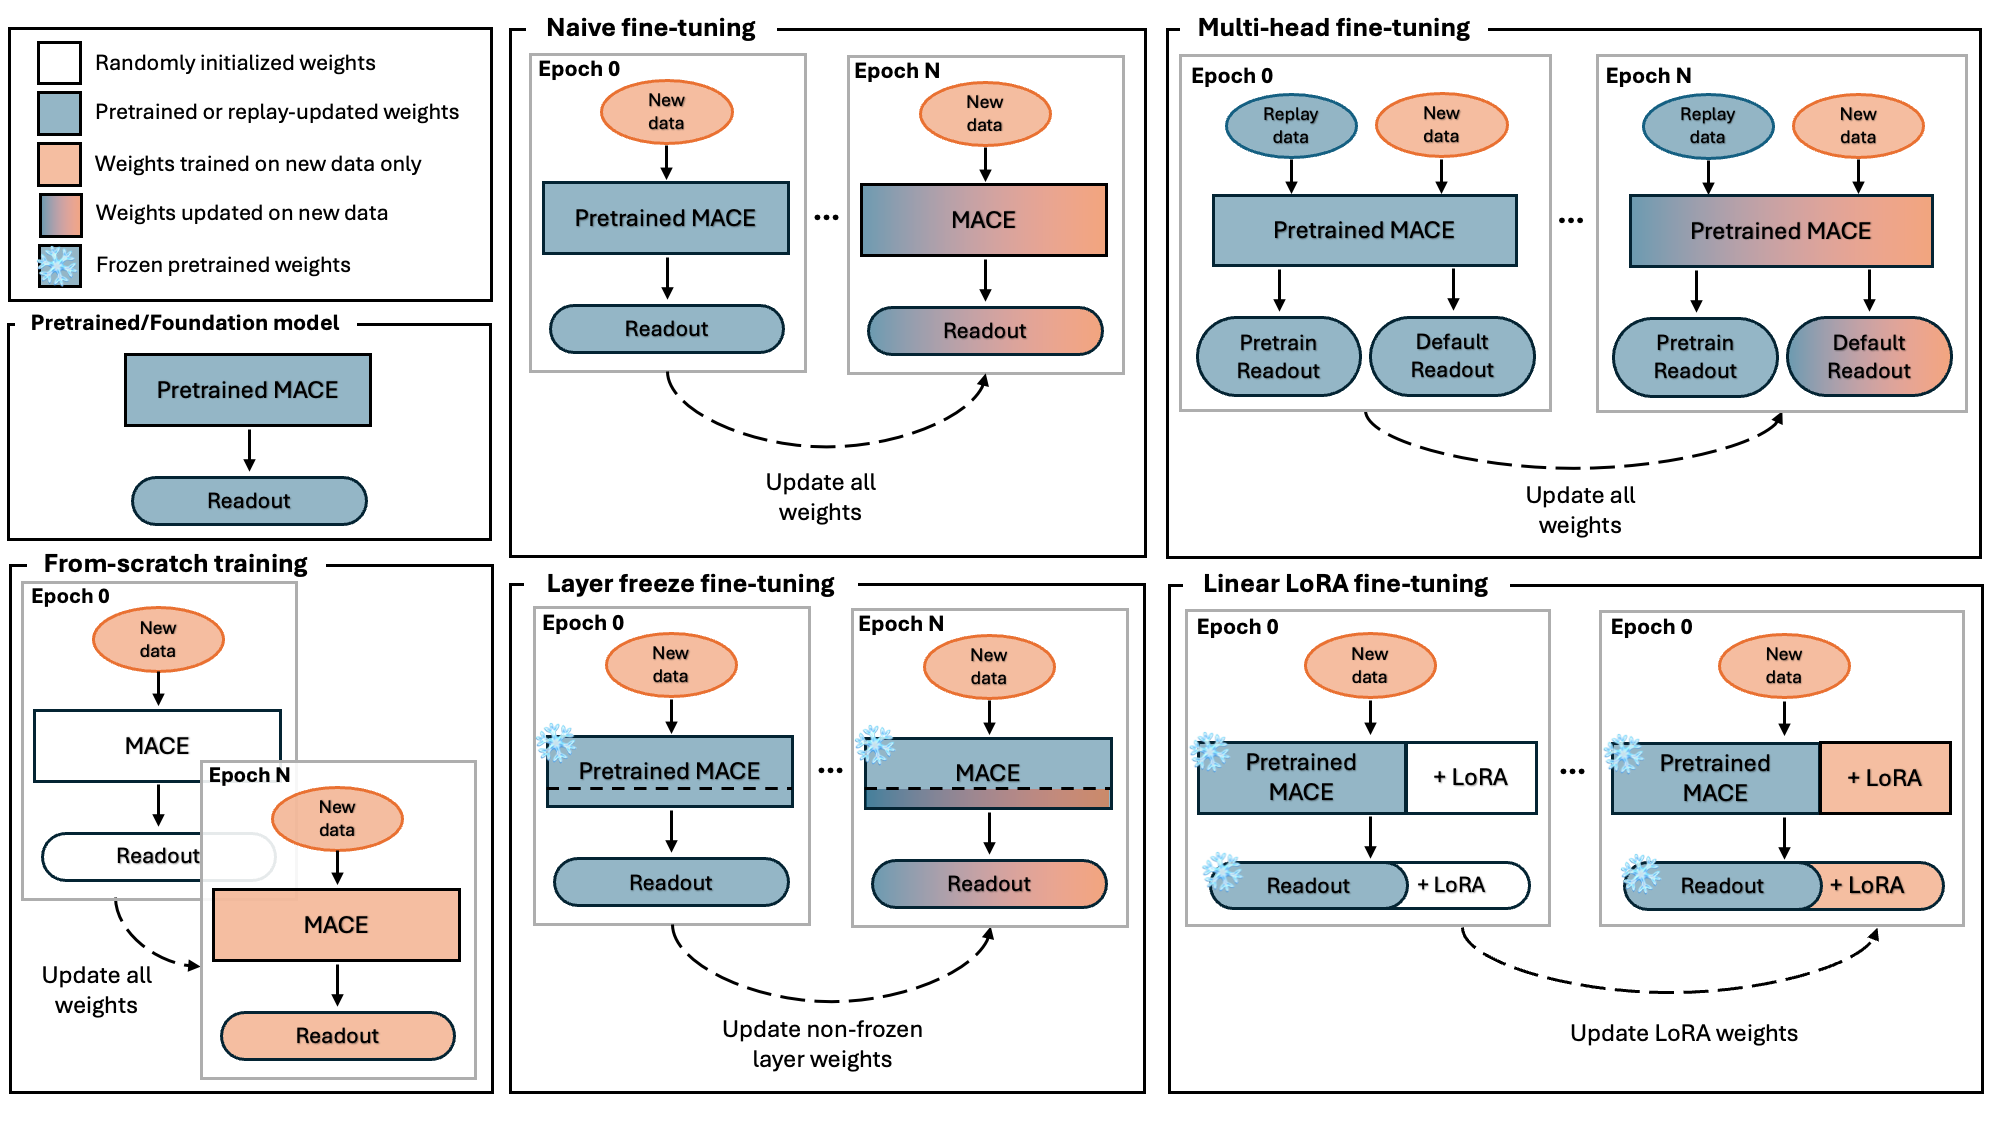

*Fine-tuning strategies from [Fine-tuning MLIP foundation models: strategies for accuracy and transferability](https://arxiv.org/abs/2606.12704). Blue denotes pretrained or replay-updated weights, orange denotes weights updated only on the new data, and snowflakes mark frozen weights.*

**Naive fine-tuning** updates every weight on the new data. **Layer freezing** updates only the unfrozen final layers. **Linear LoRA** keeps the pretrained weights fixed and learns low-rank adapters. **Multi-head fine-tuning with pseudolabel replay** retains a pretraining head and mixes replay structures with the new data to help preserve transferability.

Each strategy needs optimiser settings suited to its update rule; these differ from the defaults used for training from scratch:

| method | learning rate | EMA decay | gradient clip | method flag |
|---|---:|---:|---:|---|
| naive | `1e-3` | `0.999` | `1.0` | update all parameters |
| freeze-5 (preferred) / freeze-6 | `1e-3` | `0.999` | `1.0` | `--freeze=5` / `--freeze=6` |
| LoRA, rank 4–64 | `1e-2` | `0.99` | `10.0` | `--lora=True --lora_rank=4` |
| multihead / pseudolabel replay | `1e-4` | `0.9999` | `1.0` | two heads + replay structures |
| replay + LoRA | `1e-3` | `0.999` | `10.0` | combine both flags; generally not recommended |


In [3]:
import shlex
import subprocess

DEVICE = os.environ.get("MACE_TUTORIAL_DEVICE", "cuda")
N_EPOCHS = 50  # command smoke test; use ~1000 plus convergence checks for the paper-scale run

COMMON_FLAGS = [
    "--foundation_model=medium-omat-0",
    f"--train_file={LOCAL['train_estimated']}",
    f"--valid_file={LOCAL['valid']}",
    f"--test_file={LOCAL['test']}",
    "--energy_key=mp2_energy",
    "--forces_key=mp2_forces",
    "--E0s=estimated",
    "--loss=universal",
    "--energy_weight=10",
    "--forces_weight=10",
    "--optimizer=adamw",
    "--weight_decay=0.0",
    "--scaling=rms_forces_scaling",
    "--default_dtype=float64",
    "--error_table=PerAtomRMSE",
    f"--max_num_epochs={N_EPOCHS}",
    f"--patience={N_EPOCHS}",
    "--eval_interval=1",
    "--seed=1",
    f"--device={DEVICE}",
    "--ema",
    "--amsgrad",
    "--save_cpu",
]

METHOD_FLAGS = {
    "naive": [
        "--multiheads_finetuning=False", "--lr=1e-3", "--ema_decay=0.999",
        "--clip_grad=1.0", "--batch_size=2",
    ],
    "freeze_5": [
        "--multiheads_finetuning=False", "--freeze=5", "--lr=1e-3",
        "--ema_decay=0.999", "--clip_grad=1.0", "--batch_size=2",
    ],
    "lora_r4": [
        "--multiheads_finetuning=False", "--lora=True", "--lora_rank=4",
        "--lora_alpha=1.0", "--lr=1e-2", "--ema_decay=0.99",
        "--clip_grad=10.0", "--batch_size=2",
    ],
    "pseudolabel_replay": [
        "--multiheads_finetuning=True", "--pseudolabel_replay=True",
        f"--pt_train_file={LOCAL['replay']}", "--num_samples_pt=3706",
        "--weight_pt_head=1.0", "--force_mh_ft_lr=True", "--lr=1e-4",
        "--ema_decay=0.9999", "--clip_grad=1.0", "--batch_size=8",
    ],
}

def training_command(method):
    if method not in METHOD_FLAGS:
        raise KeyError(f"Choose one of {tuple(METHOD_FLAGS)}")
    run_dir = WORK / "runs" / method
    run_dir.mkdir(parents=True, exist_ok=True)
    return [
        "mace_run_train", f"--name=sn2_{method}", f"--work_dir={run_dir}",
        *COMMON_FLAGS, *METHOD_FLAGS[method],
    ]

def format_command(command):
    separator = " " + chr(92) + "\n    "
    return separator.join(shlex.quote(token) for token in command)

SELECTED_METHOD = "naive"
print(format_command(training_command(SELECTED_METHOD)))

mace_run_train \
    --name=sn2_naive \
    --work_dir=finetuning_tutorial_work/runs/naive \
    --foundation_model=medium-omat-0 \
    --train_file=finetuning_tutorial_work/paper_data/sn2/evals_additional/sn2-avg_vs_est_E0/data/train.xyz \
    --valid_file=finetuning_tutorial_work/paper_data/sn2/data/valid.xyz \
    --test_file=finetuning_tutorial_work/paper_data/sn2/data/test.xyz \
    --energy_key=mp2_energy \
    --forces_key=mp2_forces \
    --E0s=estimated \
    --loss=universal \
    --energy_weight=10 \
    --forces_weight=10 \
    --optimizer=adamw \
    --weight_decay=0.0 \
    --scaling=rms_forces_scaling \
    --default_dtype=float64 \
    --error_table=PerAtomRMSE \
    --max_num_epochs=50 \
    --patience=50 \
    --eval_interval=1 \
    --seed=1 \
    --device=cuda \
    --ema \
    --amsgrad \
    --save_cpu \
    --multiheads_finetuning=False \
    --lr=1e-3 \
    --ema_decay=0.999 \
    --clip_grad=1.0 \
    --batch_size=2


Set `SELECTED_METHOD` to `naive`, `freeze_5`, `lora_r4`, or `pseudolabel_replay` and inspect the generated command. In current MACE, multihead training automatically substitutes its own LR/EMA defaults unless `--force_mh_ft_lr=True`; the flag is used here so the explicit paper settings (including EMA `0.9999`) are retained.

The replay file already carries `config_energy_weight=0.1`. Together with the global energy weight of 10, this gives the replay head an effective energy weight of 1 while keeping its force weight at 10, matching the foundation objective.


In [4]:
RUN_TRAINING = False
METHODS_TO_RUN = (SELECTED_METHOD,)

def version_tuple(version):
    match = re.match(r"(\d+)\.(\d+)\.(\d+)", version or "")
    return tuple(map(int, match.groups())) if match else (0, 0, 0)

if RUN_TRAINING:
    if shutil.which("mace_run_train") is None:
        raise RuntimeError("mace_run_train is missing; install mace-torch>=0.3.15")
    if version_tuple(MACE_VERSION) < (0, 3, 15):
        raise RuntimeError(f"mace-torch>=0.3.15 is required; found {MACE_VERSION!r}")
    for method in METHODS_TO_RUN:
        print(f"\nTraining {method} ...")
        subprocess.run(training_command(method), check=True)
else:
    print("Training skipped. Set RUN_TRAINING=True after checking the command and GPU allocation.")

Training skipped. Set RUN_TRAINING=True after checking the command and GPU allocation.


## 4. A large learning rate is detrimental for multihead replay


The following archived S$_\mathrm{N}$2 runs differ only in learning rate. We plot validation loss for the target (`Default`) and replay (`pt_head`) heads through epoch 499, matching the appendix comparison.

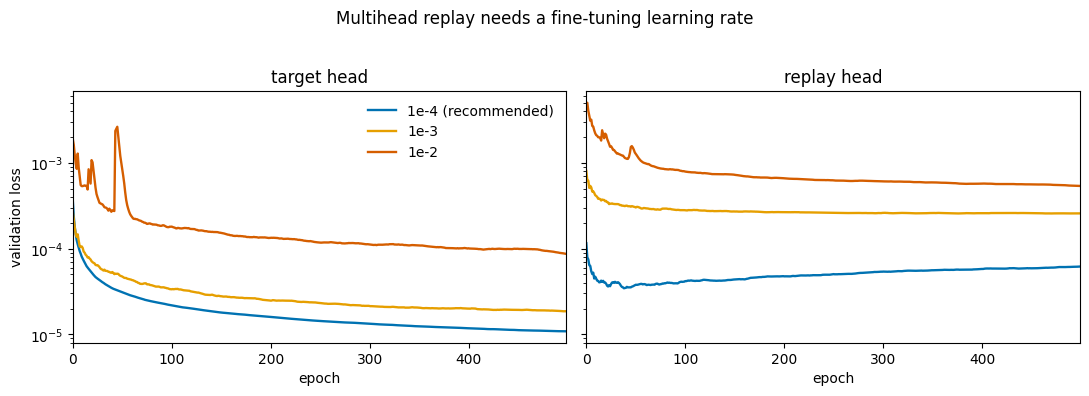

Final recorded force RMSE at/before epoch 499 (meV/Å):
  1e-4 (recommended) target=    4.8   replay=   84.5
  1e-3               target=    6.8   replay=  227.9
  1e-2               target=   18.0   replay=  303.8


In [5]:
NUMBER = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?"
METRIC_RE = re.compile(
    rf"Epoch\s+(?P<epoch>\d+):\s+head:\s+(?P<head>[^,]+),\s+"
    rf"loss=(?P<loss>{NUMBER}),\s+RMSE_E_per_atom=\s*(?P<rmse_e>{NUMBER})\s+meV,\s+"
    rf"RMSE_F=\s*(?P<rmse_f>{NUMBER})"
)

def parse_mace_metrics(path, max_epoch=None):
    # Keep the last occurrence so restarted log files remain well-defined.
    records = {}
    with path.open(errors="replace") as handle:
        for line in handle:
            match = METRIC_RE.search(line)
            if not match:
                continue
            row = match.groupdict()
            epoch = int(row["epoch"])
            if max_epoch is not None and epoch > max_epoch:
                continue
            record = {
                "epoch": epoch, "head": row["head"].strip(),
                "loss": float(row["loss"]),
                "rmse_e": float(row["rmse_e"]),
                "rmse_f": float(row["rmse_f"]),
            }
            records[(epoch, record["head"])] = record
    return sorted(records.values(), key=lambda row: (row["epoch"], row["head"]))

lr_runs = {
    "1e-4 (recommended)": LOCAL["lr_1e-4"],
    "1e-3": LOCAL["lr_1e-3"],
    "1e-2": LOCAL["lr_1e-2"],
}
colors = {"1e-4 (recommended)": "#0072B2", "1e-3": "#E69F00", "1e-2": "#D55E00"}
parsed_lr = {label: parse_mace_metrics(path, max_epoch=499) for label, path in lr_runs.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, head, title in zip(axes, ("Default", "pt_head"), ("target head", "replay head")):
    for label, records in parsed_lr.items():
        rows = [row for row in records if row["head"] == head]
        ax.plot([row["epoch"] for row in rows], [row["loss"] for row in rows],
                label=label, color=colors[label], lw=1.7)
    ax.set(title=title, xlabel="epoch", yscale="log", xlim=(0, 499))
axes[0].set_ylabel("validation loss")
axes[0].legend(frameon=False)
fig.suptitle("Multihead replay needs a fine-tuning learning rate", y=1.03)
fig.tight_layout()
plt.show()

print("Final recorded force RMSE at/before epoch 499 (meV/Å):")
for label, records in parsed_lr.items():
    values = {}
    for head in ("Default", "pt_head"):
        rows = [row for row in records if row["head"] == head]
        values[head] = max(rows, key=lambda row: row["epoch"])["rmse_f"]
    print(f"  {label:18s} target={values['Default']:7.1f}   replay={values['pt_head']:7.1f}")

At `1e-3`, the target head can still appear decent while the replay loss and force error have already increased sharply. At `1e-2`, both objectives are destabilised.

This is why the same `1e-2` that is a sensible LoRA starting point is not a sensible multihead starting point. Compare methods only after giving each one stable optimiser settings.

## 5. Stage Two (legacy alias: `swa`) can kick the model out of its local basin

Older MACE examples often enable `--swa`. In current MACE the clearer name is `--stage_two`: it changes the learning rate and loss weights at a chosen epoch (and begins the averaged-model stage). The paper's ablation isolates the disruptive loss-weight transition.

Here the constant baseline keeps target energy/force weights at 10/10. The staged runs switch from 1/10 to 10/1 at epoch 500; one keeps LR `5e-4`, and the other halves it to `2.5e-4`.

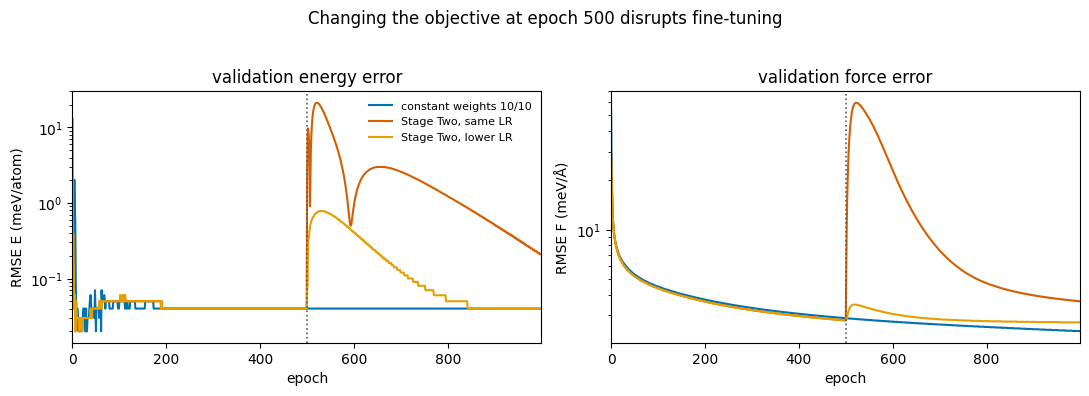

In [6]:
stage_runs = {
    "constant weights 10/10": LOCAL["stage_constant"],
    "Stage Two, same LR": LOCAL["stage_same_lr"],
    "Stage Two, lower LR": LOCAL["stage_lower_lr"],
}
stage_colors = {
    "constant weights 10/10": "#0072B2",
    "Stage Two, same LR": "#D55E00",
    "Stage Two, lower LR": "#E69F00",
}
parsed_stage = {label: parse_mace_metrics(path, max_epoch=999) for label, path in stage_runs.items()}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, metric, title, ylabel in zip(
    axes, ("rmse_e", "rmse_f"),
    ("validation energy error", "validation force error"),
    ("RMSE E (meV/atom)", "RMSE F (meV/Å)"),
):
    for label, records in parsed_stage.items():
        rows = [row for row in records if row["head"] == "Default"]
        ax.plot([row["epoch"] for row in rows], [row[metric] for row in rows],
                label=label, color=stage_colors[label], lw=1.5)
    ax.axvline(500, color="0.35", ls=":", lw=1.2)
    ax.set(title=title, xlabel="epoch", ylabel=ylabel, yscale="log", xlim=(0, 999))
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Changing the objective at epoch 500 disrupts fine-tuning", y=1.03)
fig.tight_layout()
plt.show()

The unchanged-LR transition produces an immediate error spike. Lowering the Stage-Two LR suppresses the transient, but does not improve on the constant-weight baseline. A foundation model already starts in a region with coherent forces and useful interaction physics; abruptly changing the objective can produce large gradients that push it away from that local basin. For finetuning, omit `--stage_two`/`--swa` and keep the target weights constant.

## 6. What should you run first?

1. Evaluate the foundation model before fitting. If the initial energy residual is very large, compare explicit and estimated E0 conventions before tuning the optimiser. Forces are not affected by the E0s, and can give a more accurate idea about a model's accuracy on the target data than energies.
2. Start with **naive fine-tuning** for one narrow deployment task. Use **freeze-5** or **LoRA** only when you deliberately want to test constraining adaptation.
3. Use **pseudolabel replay** when the model must remain robust for broad screening, structure search, or chemistry outside the target data. It costs more because it processes replay data and converges slower due to a lower LR.
4. Validate an observable that exercises the intended physics: an NEB barrier or dissociation scan for a reaction, RDFs and stability for MD, or short-range/RSS tests for broad exploration. Held-out RMSE is necessary, but not sufficient.
5. For deployment of a multihead model, select the target head (`default`) explicitly or extract it with `mace_select_head`.

**Exercise:** replace `SELECTED_METHOD` with two strategies, train them with the same split, and compare both the S$_\mathrm{N}$2 test error and a relaxed NEB profile. Which method would you choose if the model were later used for unrelated structure searches?

### Sources

- [Fine-tuning MLIP foundation models: strategies for accuracy and transferability](https://arxiv.org/abs/2606.12704)
- [Pinned supplementary dataset revision](https://huggingface.co/datasets/ev-tlt/MACE_finetuning_supplementary/tree/e132ea4317a4cd1426498af8cfca24ebe88fd498)
- [MACE fine-tuning documentation](https://mace-docs.readthedocs.io/en/latest/guide/finetuning.html)
- [MACE tutorial index](https://mace-docs.readthedocs.io/en/latest/examples/tutorials.html)